# 01 — EDA Sondajes de Producción (Blast Holes)
**Objetivo:** Entender la distribución espacial, de leyes y litología de los BH por banco.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')

BH_PATH = Path('../Documentacion/Referencias/Datos Demo/Data_BH')

collar = pd.read_csv(BH_PATH / 'collar.csv')
assay  = pd.read_csv(BH_PATH / 'assay.csv')
litho  = pd.read_csv(BH_PATH / 'litho.csv')

print(f'Collar: {collar.shape} | Assay: {assay.shape} | Litho: {litho.shape}')

Collar: (18521, 17) | Assay: (17127, 35) | Litho: (18604, 26)


## 1. Distribución de pozos por banco

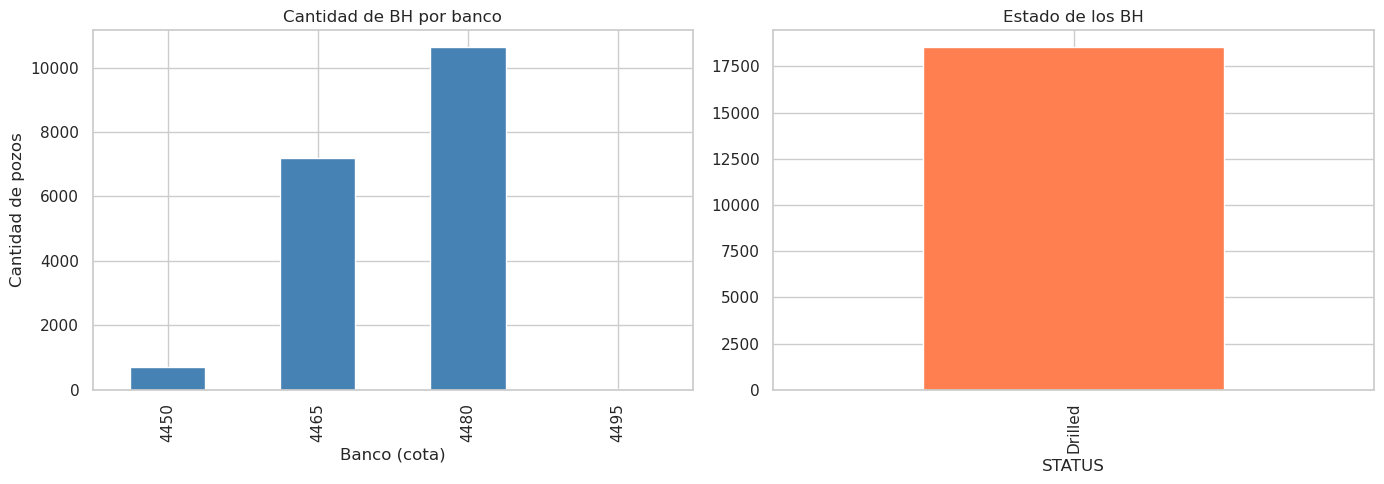

BANCO
4450      700
4465     7190
4480    10623
4495        8
Name: count, dtype: int64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por banco
banco_cnt = collar['BANCO'].value_counts().sort_index()
banco_cnt.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Cantidad de BH por banco')
axes[0].set_xlabel('Banco (cota)')
axes[0].set_ylabel('Cantidad de pozos')

# Conteo por STATUS
collar['STATUS'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Estado de los BH')

plt.tight_layout()
plt.show()
print(collar['BANCO'].value_counts().sort_index())

## 2. Mapa planta — posición espacial de collares

/tmp/ipykernel_33671/3714134318.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', len(bancos))


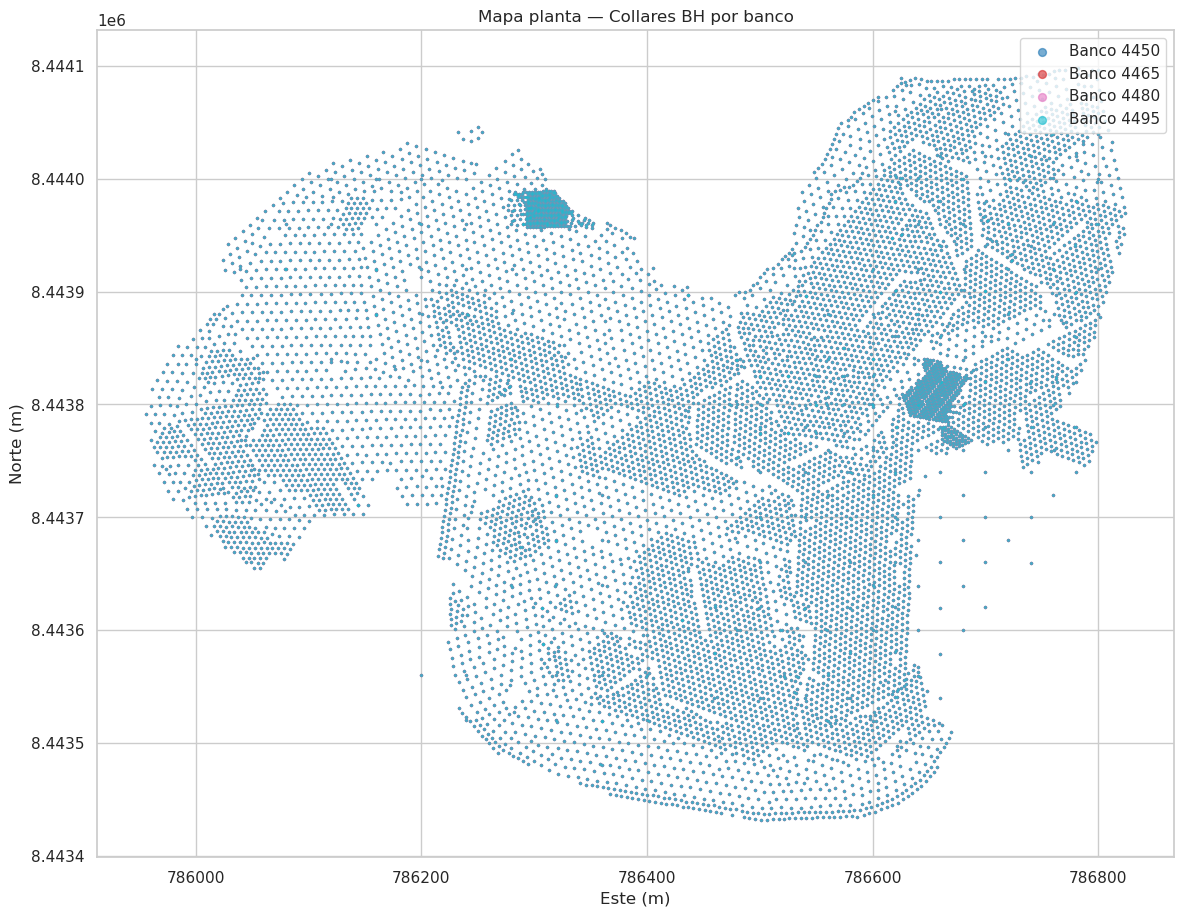

In [3]:
fig, ax = plt.subplots(figsize=(12, 10))

bancos = sorted(collar['BANCO'].dropna().unique())
cmap   = plt.cm.get_cmap('tab10', len(bancos))

for i, banco in enumerate(bancos):
    sub = collar[collar['BANCO'] == 4480] # Filtrar por 'banco'
    ax.scatter(sub['EAST'], sub['NORTH'], s=2, color=cmap(i),
               label=f'Banco {int(banco)}', alpha=0.6)

ax.set_xlabel('Este (m)')
ax.set_ylabel('Norte (m)')
ax.set_title('Mapa planta — Collares BH por banco')
ax.legend(loc='upper right', markerscale=4)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 3. Merge collar + assay y análisis de ley CU

In [4]:
df = collar.merge(assay[['HOLEID', 'CU', 'AU', 'MO', 'AG', 'FE', 'S']], on='HOLEID', how='left')
print(f'Dataset combinado: {df.shape}')
print(df[['CU', 'AU', 'MO']].describe().round(4))

Dataset combinado: (18521, 23)
               CU   AU          MO
count  17095.0000  0.0  17095.0000
mean       0.7500  NaN     97.7672
std        1.1577  NaN    227.9450
min        0.0010  NaN      1.0000
25%        0.1000  NaN      9.0000
50%        0.2970  NaN     27.0000
75%        0.8950  NaN     93.0000
max       18.7100  NaN   9490.0000


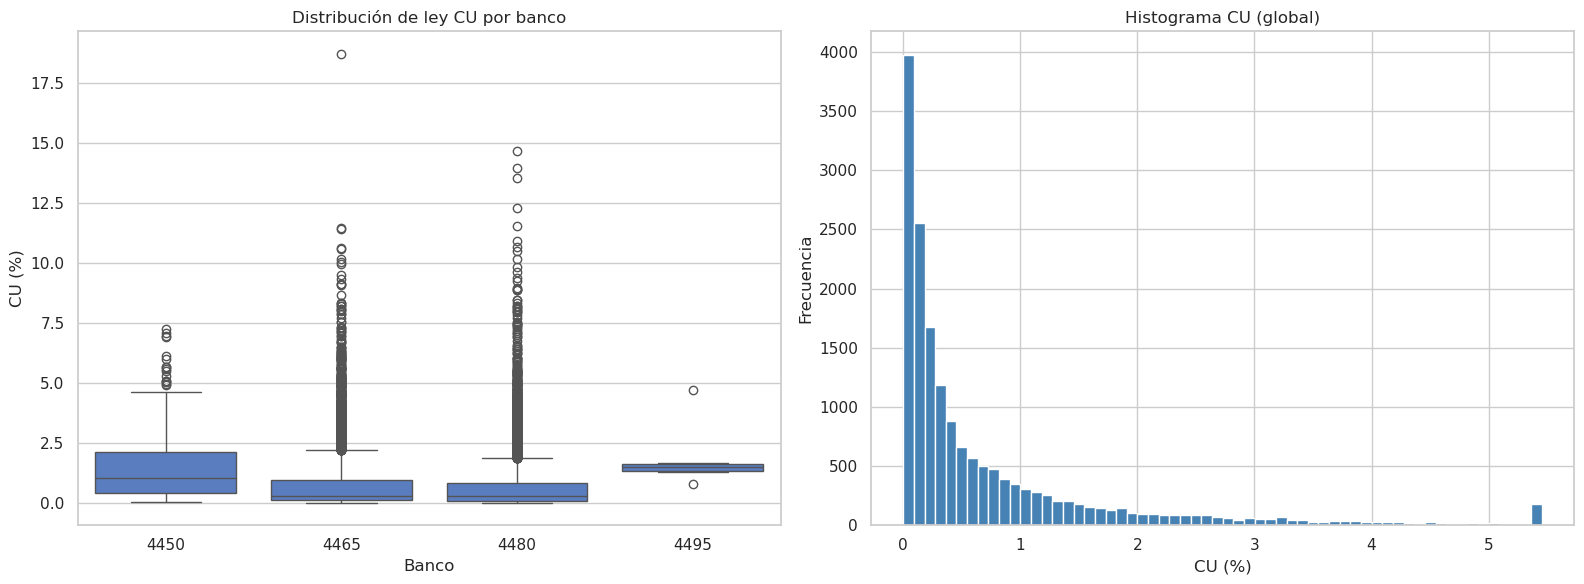

In [5]:
# Distribución de CU por banco
bancos_validos = df.dropna(subset=['BANCO', 'CU'])
bancos_validos['BANCO'] = bancos_validos['BANCO'].astype(int).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(data=bancos_validos, x='BANCO', y='CU',
            order=[str(b) for b in sorted(bancos_validos['BANCO'].astype(int).unique())],
            ax=axes[0])
axes[0].set_title('Distribución de ley CU por banco')
axes[0].set_xlabel('Banco')
axes[0].set_ylabel('CU (%)')

# Histograma global
bancos_validos['CU'].clip(upper=bancos_validos['CU'].quantile(0.99)).hist(
    bins=60, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Histograma CU (global)')
axes[1].set_xlabel('CU (%)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 4. Litología — distribución por banco

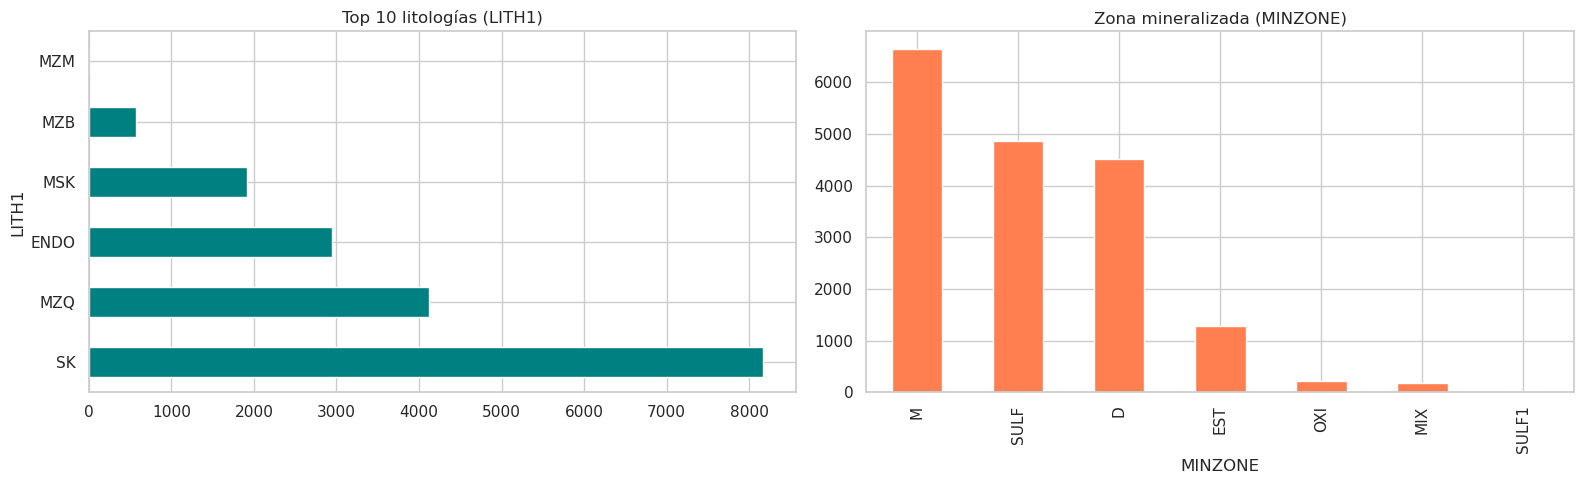

MINZONE
M        6652
SULF     4858
D        4522
EST      1280
OXI       216
MIX       174
SULF1      15
Name: count, dtype: int64


In [6]:
df_lith = collar.merge(litho[['HOLEID', 'MATERIAL', 'LITH1', 'MINZONE', 'HARDNESS']], on='HOLEID', how='left')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LITH1 top 10
top_lith = df_lith['LITH1'].value_counts().head(10)
top_lith.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 10 litologías (LITH1)')

# MINZONE
df_lith['MINZONE'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Zona mineralizada (MINZONE)')

plt.tight_layout()
plt.show()
print(df_lith['MINZONE'].value_counts())

## 5. CU promedio por banco y MINZONE

CU promedio por banco y zona mineralizada:
MINZONE       D     EST       M     MIX     OXI    SULF   SULF1
BANCO                                                          
4450     0.6381     NaN  1.4076  2.0928  1.5836  1.3435     NaN
4465     0.2814  0.1449  1.2512  1.1389  1.1468  0.8603     NaN
4480     0.2572  0.2409  0.8415  0.3703     NaN  0.9419  0.8197
4495     1.2170     NaN     NaN  2.2412     NaN     NaN     NaN


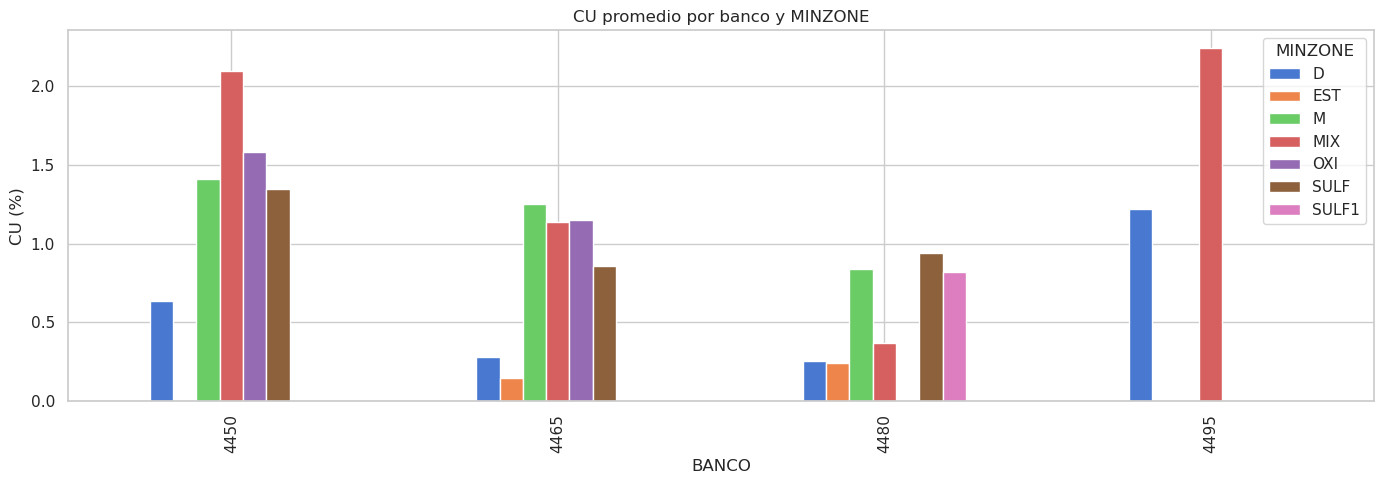

In [7]:
df_full = df.merge(litho[['HOLEID', 'MINZONE', 'LITH1']], on='HOLEID', how='left')

pivot = df_full.groupby(['BANCO', 'MINZONE'])['CU'].mean().unstack().round(4)
print('CU promedio por banco y zona mineralizada:')
print(pivot)

pivot.plot(kind='bar', figsize=(14, 5))
plt.title('CU promedio por banco y MINZONE')
plt.ylabel('CU (%)')
plt.tight_layout()
plt.show()